# Getting Started: `DomainBridge` — Symbolic Planning Integration

`DomainBridge` is a generic bridge between a PDDL domain file and robot manipulation. Instead of hard-coding predicate evaluators and action executors for each domain (as the tabletop and blocks domains do), it lets you wire them up at runtime by registering Python callables.

This notebook covers:

1. Loading and inspecting a PDDL domain
2. Registering predicate evaluators — *code-evaluated* and *fluent*
3. Registering action executors
4. Grounding symbolic state from simulation
5. Sampling a random initial scene
6. Planning with unified-planning
7. Executing a plan and tracing state evolution

Everything runs **headless** using a minimal Python stub in place of a real `FrankaEnvironment`. The same `DomainBridge` object works unchanged when you swap the stub for an actual MuJoCo simulation.

In [ ]:
import io
import itertools
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, Image
import unified_planning.shortcuts as up_shortcuts

import tampanda
from tampanda.tamp import DomainBridge

# Suppress UP engine credits in output
up_shortcuts.get_environment().credits_stream = None

BLOCKS_PDDL = (
    Path(tampanda.__file__).parent
    / "symbolic" / "domains" / "blocks" / "pddl" / "blocks_domain.pddl"
)

# ── TAMPanda CI palette ────────────────────────────────────────────────────
_BG    = "#0d0d12"
_FG    = "#f2ece8"
_TABLE = "#1c0b26"
_GRID  = "#bf5fcf"

BLOCK_COLORS = ["#bf5fcf", "#3cc0b8", "#9257b1", "#7eecdf", "#c673d0", "#7ca6b4"]


def show_fig(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=110, facecolor=_BG)
    buf.seek(0)
    display(Image(buf.read()))
    plt.close(fig)


def _draw_blocks_on_ax(ax, state, objects, title=""):
    """Render a blocks-world state onto *ax* using the TAMPanda dark theme."""
    blocks   = objects["block"]
    grippers = objects.get("gripper", [])
    color    = {b: BLOCK_COLORS[i % len(BLOCK_COLORS)] for i, b in enumerate(blocks)}

    on_pairs = [(t, b) for t in blocks for b in blocks if state.get(("on", t, b), False)]
    held     = {b for b in blocks for g in grippers if state.get(("holding", g, b), False)}
    on_table = [b for b in blocks if state.get(("on-table", b), False) and b not in held]

    def stack_level(block):
        for t, bot in on_pairs:
            if t == block:
                return stack_level(bot) + 1
        return 0

    stacked_tops = {t for t, _ in on_pairs}
    bases = [b for b in on_table if b not in stacked_tops]

    def base_of(block):
        for t, bot in on_pairs:
            if t == block:
                return base_of(bot)
        return block

    col_x  = {b: i * 1.8 + 0.9 for i, b in enumerate(bases)}
    W, H   = 0.8, 0.7
    n_cols = max(1, len(bases) + len(held))

    ax.set_facecolor(_BG)

    # Table surface
    ax.fill_between([-0.2, n_cols * 1.8 + 0.4], -H * 0.5, 0,
                    color=_TABLE, zorder=0)
    ax.axhline(0, color=_GRID, linewidth=0.8, alpha=0.25, zorder=1)

    # Blocks on table / stacked
    for block in [b for b in blocks if b not in held]:
        base = base_of(block)
        x    = col_x.get(base, 0)
        y    = stack_level(block) * H
        rect = mpatches.FancyBboxPatch(
            (x - W / 2, y), W, H,
            boxstyle="round,pad=0.04",
            facecolor=color[block], edgecolor=_BG, linewidth=1.5, zorder=2
        )
        ax.add_patch(rect)
        ax.text(x, y + H / 2, block, ha="center", va="center",
                fontsize=10, fontweight="bold", color=_BG,
                fontfamily="monospace", zorder=3)

    # Held blocks (floating, with gripper marker)
    for i, block in enumerate(held):
        x = len(bases) * 1.8 + i * 1.8 + 0.9
        y = H * 2.2
        ax.plot([x, x], [y + H, y + H + 0.35], color=_GRID,
                linewidth=1, linestyle="--", alpha=0.5, zorder=2)
        ax.text(x, y + H + 0.08, "✊", ha="center", fontsize=16, zorder=3)
        rect = mpatches.FancyBboxPatch(
            (x - W / 2, y), W, H,
            boxstyle="round,pad=0.04",
            facecolor=color[block], edgecolor=_BG, linewidth=1.5, zorder=2
        )
        ax.add_patch(rect)
        ax.text(x, y + H / 2, block, ha="center", va="center",
                fontsize=10, fontweight="bold", color=_BG,
                fontfamily="monospace", zorder=3)

    ax.set_xlim(-0.3, n_cols * 1.8 + 0.5)
    ax.set_ylim(-H * 0.6, H * 5)
    ax.set_aspect("equal")
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=11, pad=8, color=_FG, fontfamily="monospace")


def draw_blocks_state(state, objects, title=""):
    """Side-view diagram of a blocks-world state (TAMPanda dark theme)."""
    blocks   = objects["block"]
    grippers = objects.get("gripper", [])
    held     = {b for b in blocks for g in grippers if state.get(("holding", g, b), False)}
    on_table = [b for b in blocks if state.get(("on-table", b), False) and b not in held]
    on_pairs = [(t, b) for t in blocks for b in blocks if state.get(("on", t, b), False)]
    stacked_tops = {t for t, _ in on_pairs}
    bases    = [b for b in on_table if b not in stacked_tops]
    n_cols   = max(1, len(bases) + len(held))

    fig, ax = plt.subplots(figsize=(max(5, n_cols * 2 + 1), 4))
    fig.patch.set_facecolor(_BG)
    _draw_blocks_on_ax(ax, state, objects, title=title)
    plt.tight_layout()
    return fig


print("Imports OK")


---
## 1. Loading and Inspecting a PDDL Domain

`DomainBridge` reads any PDDL domain file via **unified-planning**'s `PDDLReader`. No domain-specific code is needed — types, predicates, and actions are parsed automatically. The second argument is the environment: any object you want your predicate evaluators and action executors to receive.

In [3]:
# We pass `None` as the environment here to inspect the domain before wiring it up.
domain = DomainBridge(BLOCKS_PDDL, environment=None)

print(domain.describe())

Domain: blocks-world
  Types:             ['block', 'gripper']
  Predicates:        ['on', 'on-table', 'clear', 'holding', 'gripper-empty']
  Actions:           ['pick-from-table', 'place-on-table', 'stack', 'unstack']
  Code predicates:   []
  Fluent predicates: []
  Action executors:  []
  Samplers:          []


---
## 2. Stub Environment

`DomainBridge` does not assume MuJoCo — the `environment` argument is whatever you want your predicate functions and action executors to receive. Below we define a minimal Python class that tracks block positions and stacking state. In a real TAMP pipeline you would pass a `FrankaEnvironment` instance instead.

In [5]:
class BlocksSim:
    """Minimal blocks-world simulation: positions + stacking, no physics."""

    HALF    = 0.04   # block half-size [m]
    TABLE_Z = 0.27   # table surface height [m]

    def __init__(self, block_names):
        self.block_names = list(block_names)
        # Place blocks on the table, spaced 12 cm apart
        self.pos = {
            b: np.array([0.35 + i * 0.12, 0.0, self.TABLE_Z + self.HALF])
            for i, b in enumerate(block_names)
        }

    def lift(self, block):
        """Move block to a lifted position (simulates picking)."""
        p = self.pos[block].copy()
        p[2] = self.TABLE_Z + 6 * self.HALF
        self.pos[block] = p

    def place_on_table(self, block, x=None):
        """Place block flat on the table."""
        x = x if x is not None else self.pos[block][0]
        self.pos[block] = np.array([x, 0.0, self.TABLE_Z + self.HALF])

    def stack_on(self, top, bot):
        """Place `top` directly on top of `bot`."""
        p = self.pos[bot].copy()
        p[2] += 2 * self.HALF
        self.pos[top] = p


sim = BlocksSim(["b0", "b1", "b2"])
print("Block positions:")
for name, pos in sim.pos.items():
    print(f"  {name}: {np.round(pos, 3)}")

Block positions:
  b0: [0.35 0.   0.31]
  b1: [0.47 0.   0.31]
  b2: [0.59 0.   0.31]


---
## 3. Registering Predicates

There are two kinds of predicates:

| Kind | Registered with | Evaluated when |
|---|---|---|
| **Code-evaluated** | `@domain.predicate(name)` | Every `ground_state()` call, for all type-consistent object combinations |
| **Fluent** | `domain.fluent(name, initial=...)` | Not re-evaluated — truth is tracked through action effects |

Code-evaluated predicates receive `(env, fluent_state, *objects)` and return `bool`. They are the right choice for anything that can be read from the simulation geometry — positions, heights, overlaps. Fluent predicates are better for state that *only changes when an action succeeds*, such as which object the gripper is holding.

In [6]:
domain = DomainBridge(BLOCKS_PDDL, environment=sim)

OVERLAP = 0.6  # fraction of half-size; controls how centred a block must be to count as "on"


# ── Code-evaluated predicates ─────────────────────────────────────────────

@domain.predicate("on")
def eval_on(sim, fluents, block_top, block_bot):
    """True when block_top rests on block_bot (z-height + xy alignment check)."""
    pt, pb = sim.pos[block_top], sim.pos[block_bot]
    dz  = pt[2] - pb[2]
    dxy = np.linalg.norm(pt[:2] - pb[:2])
    return abs(dz - 2 * sim.HALF) < 0.005 and dxy < sim.HALF * OVERLAP


@domain.predicate("on-table")
def eval_on_table(sim, fluents, block):
    """True when block is at table height (not stacked, not lifted)."""
    expected = sim.TABLE_Z + sim.HALF
    return abs(sim.pos[block][2] - expected) < 0.01


@domain.predicate("clear")
def eval_clear(sim, fluents, block):
    """True when no other block is resting on this block."""
    pb = sim.pos[block]
    for other in sim.block_names:
        if other == block:
            continue
        po  = sim.pos[other]
        dz  = po[2] - pb[2]
        dxy = np.linalg.norm(po[:2] - pb[:2])
        if abs(dz - 2 * sim.HALF) < 0.005 and dxy < sim.HALF * OVERLAP:
            return False
    return True


# ── Fluent predicates ─────────────────────────────────────────────────────
# `holding` tracks which block the gripper holds — updated by action effects.
# `gripper-empty` starts True for gripper g0 (expressed as a list of arg-tuples).

domain.fluent("holding",      initial=None)       # nothing held initially
domain.fluent("gripper-empty", initial=[("g0",)]) # g0 starts empty

print("Predicates registered.")

Predicates registered.


---
## 4. Registering Action Executors

Each PDDL action gets an executor: a Python callable that carries out the action and returns `(success: bool, fluent_delta: dict)`. The keys of `fluent_delta` are `(predicate_name, *args)` tuples — the same format used by `ground_state`. On success, the domain automatically merges the delta into its internal fluent state.

In [7]:
@domain.action("pick-from-table")
def exec_pick(sim, fluents, gripper, block):
    sim.lift(block)
    return True, {
        ("holding",      gripper, block): True,
        ("gripper-empty", gripper):       False,
    }


@domain.action("place-on-table")
def exec_place(sim, fluents, gripper, block):
    sim.place_on_table(block)
    return True, {
        ("holding",      gripper, block): False,
        ("gripper-empty", gripper):       True,
    }


@domain.action("stack")
def exec_stack(sim, fluents, gripper, block_top, block_bot):
    sim.stack_on(block_top, block_bot)
    return True, {
        ("holding",      gripper, block_top): False,
        ("gripper-empty", gripper):           True,
    }


@domain.action("unstack")
def exec_unstack(sim, fluents, gripper, block_top, block_bot):
    sim.lift(block_top)
    return True, {
        ("holding",      gripper, block_top): True,
        ("gripper-empty", gripper):           False,
    }


print(domain.describe())

Domain: blocks-world
  Types:             ['block', 'gripper']
  Predicates:        ['on', 'on-table', 'clear', 'holding', 'gripper-empty']
  Actions:           ['pick-from-table', 'place-on-table', 'stack', 'unstack']
  Code predicates:   ['on', 'on-table', 'clear']
  Fluent predicates: ['gripper-empty', 'holding']
  Action executors:  ['pick-from-table', 'place-on-table', 'stack', 'unstack']
  Samplers:          []


---
## 5. Grounding State

`ground_state(objects)` evaluates all registered predicates for every type-consistent combination of objects and returns a flat dict `{(pred, *args): bool}`. Code-evaluated predicates are called fresh each time; fluent predicates are read from the tracked state.

True predicates in initial state:
  ('clear', 'b0')
  ('clear', 'b1')
  ('clear', 'b2')
  ('gripper-empty', 'g0')
  ('on-table', 'b0')
  ('on-table', 'b1')
  ('on-table', 'b2')


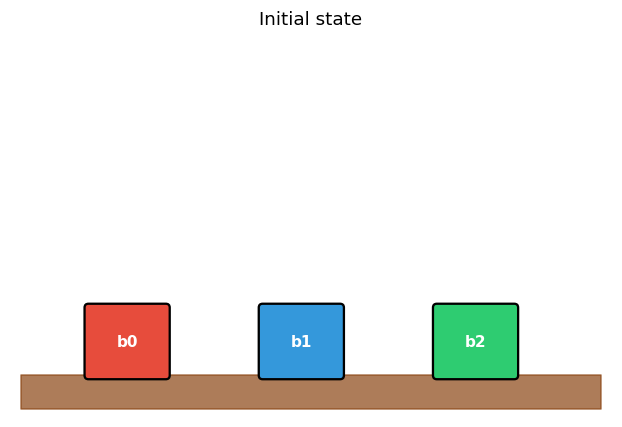

In [8]:
objects = {"block": ["b0", "b1", "b2"], "gripper": ["g0"]}

state = domain.ground_state(objects)

print("True predicates in initial state:")
for key in sorted(k for k, v in state.items() if v):
    print(f"  {key}")

fig = draw_blocks_state(state, objects, title="Initial state")
show_fig(fig)

---
## 6. Sampling a Random Scene

Register one sampler per PDDL type. Each sampler receives `(env, placed_so_far, rng)` and returns a pose (or `None` to reject). The framework retries up to `sampler_max_retries` times per object — useful for simple collision gating.

Sampled block positions:
  b0: (0.519, 0.159, 0.310)
  b1: (0.571, -0.110, 0.310)
  b2: (0.405, 0.149, 0.310)


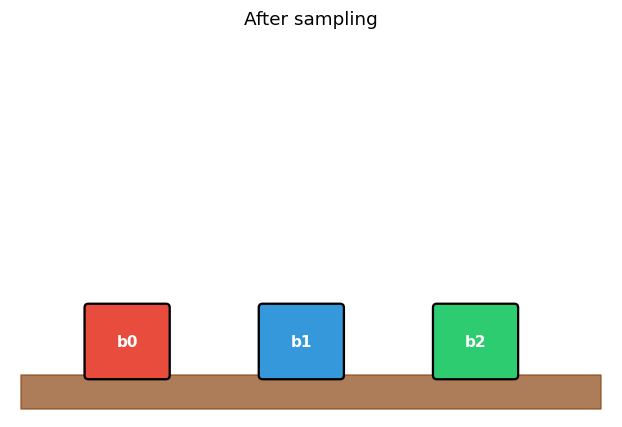

In [10]:
MIN_SPACING = 0.10  # minimum centre-to-centre distance between blocks [m]


@domain.sampler("block")
def sample_block_pose(sim, placed_so_far, rng):
    x = rng.uniform(0.30, 0.65)
    y = rng.uniform(-0.20, 0.20)
    # Reject if too close to an already-placed block
    for prev in placed_so_far:
        if np.linalg.norm(np.array([x, y]) - np.array(prev[:2])) < MIN_SPACING:
            return None
    return (x, y, sim.TABLE_Z + sim.HALF)


poses = domain.sample_random_state({"block": 3}, seed=7)

# Apply sampled positions to the stub sim
for block, pose in zip(objects["block"], poses["block"]):
    sim.pos[block] = np.array(pose)

sampled_state = domain.ground_state(objects)
print("Sampled block positions:")
for block, pose in zip(objects["block"], poses["block"]):
    print(f"  {block}: ({pose[0]:.3f}, {pose[1]:.3f}, {pose[2]:.3f})")

fig = draw_blocks_state(sampled_state, objects, title="After sampling")
show_fig(fig)

# Reset to a clean flat state for the planning section
for i, block in enumerate(objects["block"]):
    sim.place_on_table(block, x=0.35 + i * 0.12)

---
## 7. Planning

`plan(objects, goals)` grounds the current state, builds a `unified_planning.model.Problem`, and calls a planner. Goals are expressed as `(predicate_name, *object_names)` tuples. A planner must be installed — `pip install up-pyperplan` is the easiest option for STRIPS problems.

In [11]:
# Build a tower: b0 on b1 on b2
goals = [
    ("on", "b0", "b1"),
    ("on", "b1", "b2"),
]

state_before = domain.ground_state(objects)
print("State before planning:")
for key in sorted(k for k, v in state_before.items() if v):
    print(f"  {key}")

print()
plan = domain.plan(objects, goals)

if plan:
    print(f"Plan ({len(plan)} steps):")
    for step, (action, params) in enumerate(plan, 1):
        print(f"  {step}. {action}({', '.join(params)})")
else:
    print("No plan found — is a UP-compatible planner installed?")
    print("  pip install up-pyperplan")

State before planning:
  ('clear', 'b0')
  ('clear', 'b1')
  ('clear', 'b2')
  ('gripper-empty', 'g0')
  ('on-table', 'b0')
  ('on-table', 'b1')
  ('on-table', 'b2')

Plan (4 steps):
  1. pick-from-table(g0, b1)
  2. stack(g0, b1, b2)
  3. pick-from-table(g0, b0)
  4. stack(g0, b0, b1)


---
## 8. Executing a Plan

`execute_action(name, *params)` calls the registered executor, updates the internal fluent state on success, and returns `(success, fluent_delta)`. We step through the plan and visualise the symbolic state after each action.

Passing `strict_preconditions=True` at construction makes `execute_action` verify the PDDL preconditions against the grounded state before calling the executor — useful for catching bugs early.

In [ ]:
if plan:
    snapshots = []

    state = domain.ground_state(objects)
    snapshots.append(("initial", state))

    for action_name, params in plan:
        success, delta = domain.execute_action(action_name, *params)
        if not success:
            print(f"Action {action_name}{params} failed!")
            break
        state = domain.ground_state(objects)
        snapshots.append((f"{action_name}({', '.join(params)})", state))

    n   = len(snapshots)
    fig, axes = plt.subplots(1, n, figsize=(n * 3.2, 4))
    fig.patch.set_facecolor(_BG)
    if n == 1:
        axes = [axes]

    for ax, (label, snap) in zip(axes, snapshots):
        _draw_blocks_on_ax(ax, snap, objects, title=label)

    fig.suptitle("Plan execution — symbolic state after each step",
                 fontsize=10, color=_FG, fontfamily="monospace", y=1.02)
    plt.tight_layout()
    show_fig(fig)


---
## 9. Strict Precondition Checking

When `strict_preconditions=True`, `execute_action` evaluates the PDDL preconditions against the grounded state before calling the executor. Violated preconditions raise `RuntimeError`. This is useful for debugging executors and catching state-tracking bugs.

In [13]:
# Rebuild the domain with strict_preconditions=True
strict_domain = DomainBridge(BLOCKS_PDDL, environment=sim, strict_preconditions=True)

# Re-register (same definitions, different domain instance)
@strict_domain.predicate("on")
def _on(sim, fl, t, b):
    pt, pb = sim.pos[t], sim.pos[b]
    return abs(pt[2]-pb[2]-2*sim.HALF) < 0.005 and np.linalg.norm(pt[:2]-pb[:2]) < sim.HALF * OVERLAP

@strict_domain.predicate("on-table")
def _on_table(sim, fl, b): return abs(sim.pos[b][2]-(sim.TABLE_Z+sim.HALF)) < 0.01

@strict_domain.predicate("clear")
def _clear(sim, fl, b):
    for o in sim.block_names:
        if o == b: continue
        if abs(sim.pos[o][2]-sim.pos[b][2]-2*sim.HALF)<0.005 and np.linalg.norm(sim.pos[o][:2]-sim.pos[b][:2])<sim.HALF*OVERLAP:
            return False
    return True

strict_domain.fluent("holding",       initial=None)
strict_domain.fluent("gripper-empty", initial=[("g0",)])

@strict_domain.action("pick-from-table")
def _pick(sim, fl, g, b):
    sim.lift(b)
    return True, {("holding", g, b): True, ("gripper-empty", g): False}

@strict_domain.action("stack")
def _stack(sim, fl, g, t, bot):
    sim.stack_on(t, bot)
    return True, {("holding", g, t): False, ("gripper-empty", g): True}

# Reset sim to flat state
for i, block in enumerate(objects["block"]):
    sim.place_on_table(block, x=0.35 + i * 0.12)

# Valid action — should succeed
ok, _ = strict_domain.execute_action("pick-from-table", "g0", "b0", objects=objects)
print(f"pick-from-table(g0, b0): success={ok}")

# Invalid: gripper is already holding b0; gripper-empty is False
try:
    strict_domain.execute_action("pick-from-table", "g0", "b1", objects=objects)
    print("pick-from-table(g0, b1): no error (unexpected)")
except RuntimeError as e:
    print(f"pick-from-table(g0, b1): caught precondition error — {e}")

pick-from-table(g0, b0): success=True
pick-from-table(g0, b1): caught precondition error — Precondition violated for 'pick-from-table(g0, b1)'.


---
## Next Steps

| What you want | Where to look |
|---|---|
| Existing domain implementations | `tampanda/symbolic/domains/tabletop/`, `tampanda/symbolic/domains/blocks/` |
| Planning in a real MuJoCo scene | `examples/symbolic.py`, `examples/demo_pick_put.py` |
| Action feasibility checking | `tampanda/symbolic/domains/tabletop/feasibility.py` |
| Dataset generation with BFS | `python -m tampanda.symbolic.domains.tabletop.generate_data --help` |
| Arm control and grasping | `notebooks/franka_getting_started.ipynb` |
| UP planner selection | `pip install up-pyperplan` (pure Python, STRIPS) or `pip install up-fast-downward` |